In [ ]:
# # aasignment 2
# # if the template is smaller than the region you are trying to match, your
# enhanced algorithm will fix this problem.
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


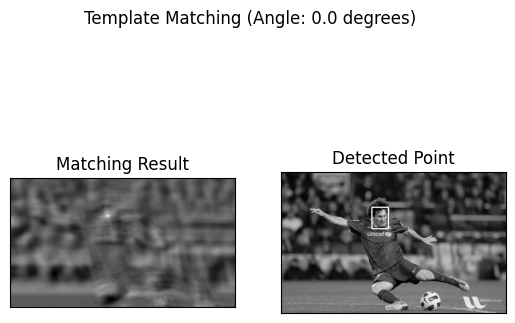

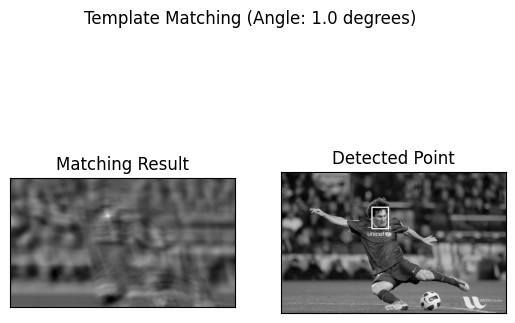

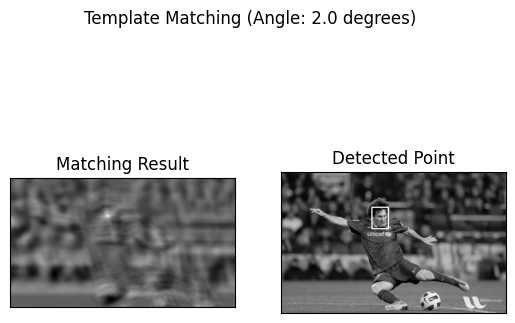

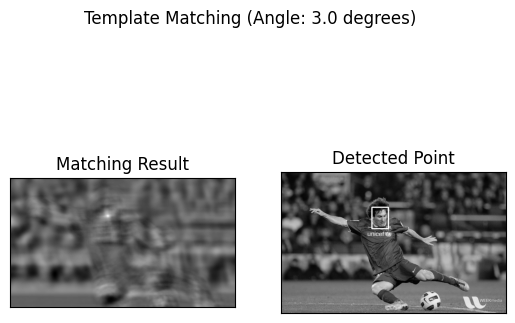

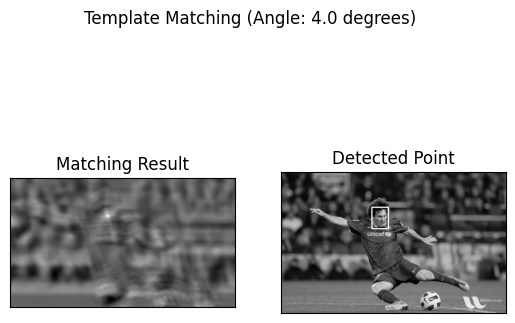

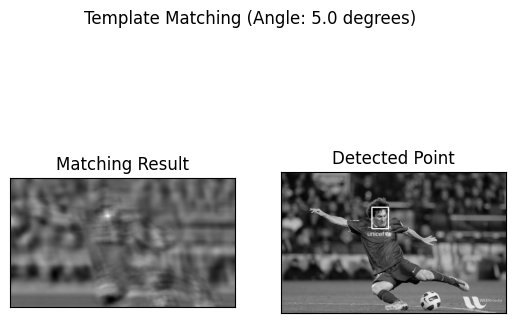

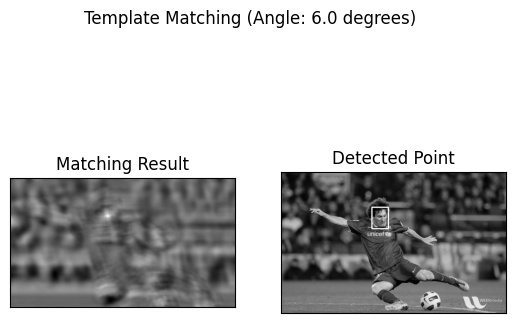

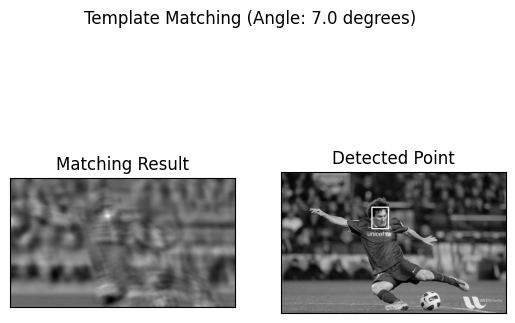

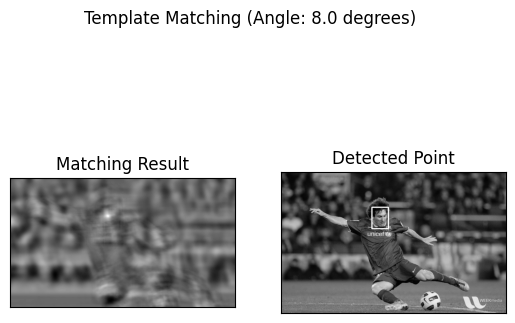

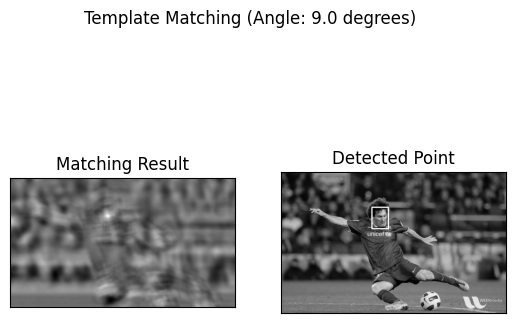

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_gray = cv2.imread('/content/gdrive/MyDrive/arwaa img/messi5.jpg', cv2.IMREAD_GRAYSCALE)
template = cv2.imread("/content/gdrive/MyDrive/arwaa img/Template.jpg", cv2.IMREAD_GRAYSCALE)

w, h = template.shape[::-1]

def rotate_image(image, angle):
    center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(center, angle, 1.0)
    result = cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return result

num_angles = 360
angles = np.arange(0, 360, 360 / num_angles)[:10]

for angle in angles:
    rotated_template = rotate_image(template, angle)
    img = img_gray.copy()

    res = cv2.matchTemplate(img, rotated_template, cv2.TM_CCOEFF)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)
    cv2.rectangle(img, top_left, bottom_right, 255, 2)

    plt.subplot(121), plt.imshow(res, cmap='gray')
    plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
    plt.subplot(122), plt.imshow(img, cmap='gray')
    plt.title('Detected Point'), plt.xticks([]), plt.yticks([])
    plt.suptitle(f'Template Matching (Angle: {angle} degrees)')
    plt.show()
